House Prices - Model Experiment


Setup

In [ ]:
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import mlflow
import mlflow.sklearn
import mlflow.xgboost

import dagshub

print('All imports successful')

All imports successful


In [2]:
os.environ['MLFLOW_TRACKING_USERNAME'] = 'sansi23'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '40232a6e77e82647fb1d4a6c4b838475b5ad16a6'

dagshub.init(
    repo_owner='sansi23',
    repo_name='House-Prices---Advanced-Regression-Techniques',
    mlflow=True
)

print(mlflow.get_tracking_uri())

Accessing as sansi23

Initialized MLflow to track repo "sansi23/House-Prices---Advanced-Regression-Techniques"

Repository sansi23/House-Prices---Advanced-Regression-Techniques initialized!

https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow


In [3]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (1460, 81)
Test shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
X = train.drop(columns=['SalePrice', 'Id'])
y = np.log1p(train['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (1168, 79)
Test size: (292, 79)


(array([  2.,   2.,   1.,   0.,   0.,   0.,   2.,   3.,   4.,   3.,   5.,
          1.,   5.,  21.,  22.,  23.,  18.,  29.,  58.,  56.,  65., 100.,
        122.,  93.,  90.,  82., 108.,  91.,  64.,  55.,  58.,  51.,  46.,
         42.,  23.,  29.,  22.,  13.,  13.,  13.,   7.,   5.,   4.,   1.,
          2.,   2.,   2.,   0.,   0.,   2.]),
 array([10.46027076, 10.52175483, 10.5832389 , 10.64472298, 10.70620705,
        10.76769112, 10.82917519, 10.89065926, 10.95214334, 11.01362741,
        11.07511148, 11.13659555, 11.19807962, 11.25956369, 11.32104777,
        11.38253184, 11.44401591, 11.50549998, 11.56698405, 11.62846813,
        11.6899522 , 11.75143627, 11.81292034, 11.87440441, 11.93588849,
        11.99737256, 12.05885663, 12.1203407 , 12.18182477, 12.24330884,
        12.30479292, 12.36627699, 12.42776106, 12.48924513, 12.5507292 ,
        12.61221328, 12.67369735, 12.73518142, 12.79666549, 12.85814956,
        12.91963363, 12.98111771, 13.04260178, 13.10408585, 13.16556992,
 

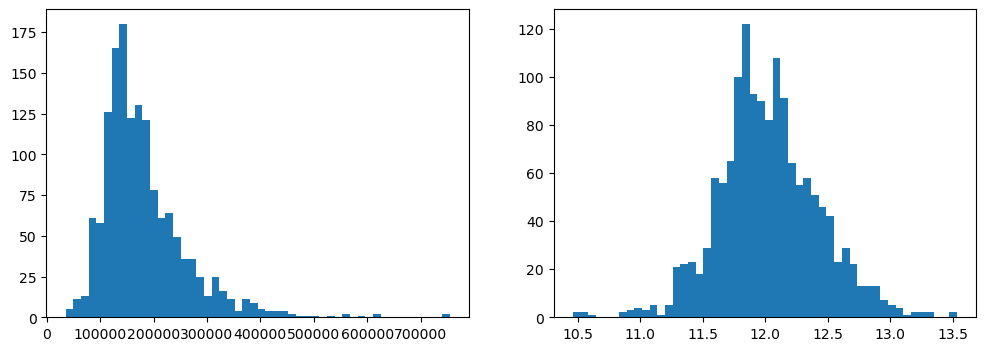

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['SalePrice'], bins=50)           
axes[1].hist(np.log1p(train['SalePrice']), bins=50) 

Data Cleaning

Missing Value Analysis

              Missing Count  Missing %
PoolQC                 1162      99.49
MiscFeature            1122      96.06
Alley                  1094      93.66
Fence                   935      80.05
MasVnrType              683      58.48
FireplaceQu             547      46.83
LotFrontage             217      18.58
GarageType               64       5.48
GarageYrBlt              64       5.48
GarageFinish             64       5.48
GarageQual               64       5.48
GarageCond               64       5.48
BsmtFinType1             28       2.40
BsmtFinType2             28       2.40
BsmtExposure             28       2.40
BsmtCond                 28       2.40
BsmtQual                 28       2.40
MasVnrArea                6       0.51
Electrical                1       0.09


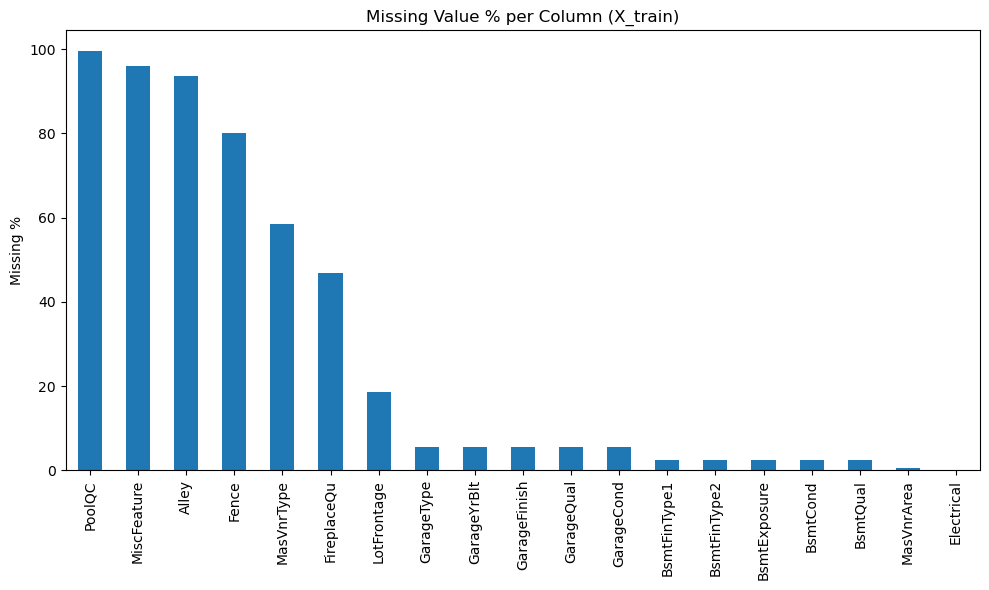

In [6]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(X_train) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df)

plt.figure(figsize=(10, 6))
missing_pct.plot(kind="bar")
plt.title("Missing Value % per Column (X_train)")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

Simple Imputation


In [30]:
def simple_impute(df_train, df_test):
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for col in df_train.columns:
        if df_train[col].isnull().any():
            if df_train[col].dtype == "object":
                fill_val = df_train[col].mode()[0]
            else:
                fill_val = df_train[col].median()
            df_train[col] = df_train[col].fillna(fill_val)
            df_test[col]  = df_test[col].fillna(fill_val)
    return df_train, df_test

X_train_s, X_test_s = simple_impute(X_train, X_test)
print("Nulls in X_train after simple imputation:", X_train_s.isnull().sum().sum())
print("Nulls in X_test  after simple imputation:", X_test_s.isnull().sum().sum())

Nulls in X_train after simple imputation: 0
Nulls in X_test  after simple imputation: 0


In [31]:
for col in X_test_s.columns:
    if X_test_s[col].isnull().any():
        if X_test_s[col].dtype == 'object':
            X_test_s[col] = X_test_s[col].fillna(X_train_s[col].mode()[0])
        else:
            X_test_s[col] = X_test_s[col].fillna(X_train_s[col].median())
print('Nulls after fix - X_test_s:', X_test_s.isnull().sum().sum())

Nulls after fix - X_test_s: 0


Outlier Removal


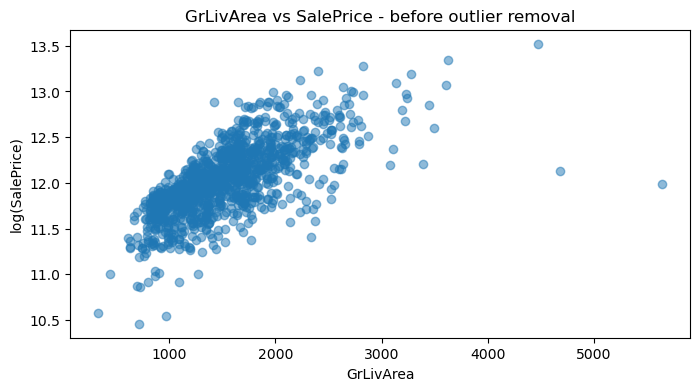

In [8]:
plt.figure(figsize=(8, 4))
plt.scatter(X_train["GrLivArea"], y_train, alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("log(SalePrice)")
plt.title("GrLivArea vs SalePrice - before outlier removal")
plt.show()

In [9]:
outlier_mask = (X_train["GrLivArea"] > 4000) & (y_train < 13.0)
print("Outliers found:", outlier_mask.sum())

X_train = X_train[~outlier_mask]
y_train = y_train[~outlier_mask]

X_train_s, X_test_s = simple_impute(X_train, X_test)

print("X_train size after outlier removal:", X_train.shape)

Outliers found: 2
X_train size after outlier removal: (1166, 79)


Feature Engineering

In [10]:
for df in [X_train_s, X_test_s]:
    df['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge']     = df['YrSold'] - df['YearBuilt']
    df['RemodAge']     = df['YrSold'] - df['YearRemodAdd']
    df['TotalBath']    = df['FullBath'] + df['HalfBath'] * 0.5 + df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5
    df['HasGarage']    = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasPool']      = (df['PoolArea'] > 0).astype(int)
    df['HasPorch']     = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] > 0).astype(int)

print("New features added. X_train_s shape:", X_train_s.shape)

New features added. X_train_s shape: (1166, 87)


One Hot Encoding

In [11]:
ohe_cols = [
    'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional',
    'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature',
    'SaleType', 'SaleCondition', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'Condition1', 'Condition2'
]

X_train_s = pd.get_dummies(X_train_s, columns=ohe_cols, drop_first=True)
X_test_s  = pd.get_dummies(X_test_s,  columns=ohe_cols, drop_first=True)

X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)

print("After OHE:")
print("X_train_s shape:", X_train_s.shape)
print("X_test_s shape: ", X_test_s.shape)

After OHE:
X_train_s shape: (1166, 175)
X_test_s shape:  (292, 175)


In [12]:
remaining_cats = X_train_s.select_dtypes(include='object').columns.tolist()
print("Remaining categorical columns:", remaining_cats)
print("Count:", len(remaining_cats))

Remaining categorical columns: ['Neighborhood', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
Count: 13


In [13]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu',
             'GarageQual', 'GarageCond', 'PoolQC']

for df in [X_train_s, X_test_s]:
    for col in qual_cols:
        df[col] = df[col].map(qual_map).fillna(0).astype(int)

print("Ordinal encoding done.")
print(X_train_s[qual_cols].head())

Ordinal encoding done.
      ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
254           3          4         3         3          3            3   
1066          4          3         4         3          4            3   
638           3          3         2         3          4            3   
799           3          3         4         3          5            4   
380           3          3         3         3          3            4   

      FireplaceQu  GarageQual  GarageCond  PoolQC  
254             4           3           3       5  
1066            3           3           3       5  
638             4           3           3       5  
799             3           3           3       5  
380             4           3           3       5  


WOE Encoding

In [14]:
y_binary = (y_train > y_train.median()).astype(int)

def woe_encode(train_col, test_col, y_binary):
    woe_map = {}
    for cat in train_col.unique():
        mask = train_col == cat
        events     = y_binary[mask].sum()
        non_events = (1 - y_binary[mask]).sum()
        total_ev   = y_binary.sum()
        total_nev  = (1 - y_binary).sum()
        dist_ev    = (events + 0.5) / total_ev
        dist_nev   = (non_events + 0.5) / total_nev
        woe_map[cat] = np.log(dist_ev / dist_nev)
    train_woe = train_col.map(woe_map).fillna(0)
    test_woe  = test_col.map(woe_map).fillna(0)
    return train_woe, test_woe

for col in ['Neighborhood', 'Exterior1st', 'Exterior2nd']:
    X_train_s[col], X_test_s[col] = woe_encode(X_train_s[col], X_test_s[col], y_binary)

print("WOE encoding done.")
print(X_train_s[['Neighborhood', 'Exterior1st', 'Exterior2nd']].head())

WOE encoding done.
      Neighborhood  Exterior1st  Exterior2nd
254      -1.269319    -1.147167    -1.150219
1066      2.628682     1.010395     1.026568
638      -1.854730    -1.147167    -1.053015
799      -0.855316    -1.038905    -1.053015
380      -0.855316     0.308522    -1.053015


In [15]:
remaining = X_train_s.select_dtypes(include='object').columns.tolist()
print("Remaining categorical columns:", remaining)

Remaining categorical columns: []


Feature Selection

Corelation Filter

In [16]:
corr_matrix = X_train_s.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.85)]

print(f"Columns with correlation > 0.85 : {len(high_corr_cols)}")
print(high_corr_cols)

X_train_corr = X_train_s.drop(columns=high_corr_cols)
X_test_corr  = X_test_s.drop(columns=high_corr_cols)

print("\nShape after correlation filter:")
print("X_train_corr:", X_train_corr.shape)
print("X_test_corr: ", X_test_corr.shape)

Columns with correlation > 0.85 : 10
['Exterior2nd', 'GarageArea', 'TotalSF', 'HouseAge', 'RemodAge', 'HasFireplace', 'HasPool', 'RoofStyle_Hip', 'SaleCondition_Partial', 'MasVnrType_Stone']

Shape after correlation filter:
X_train_corr: (1166, 165)
X_test_corr:  (292, 165)


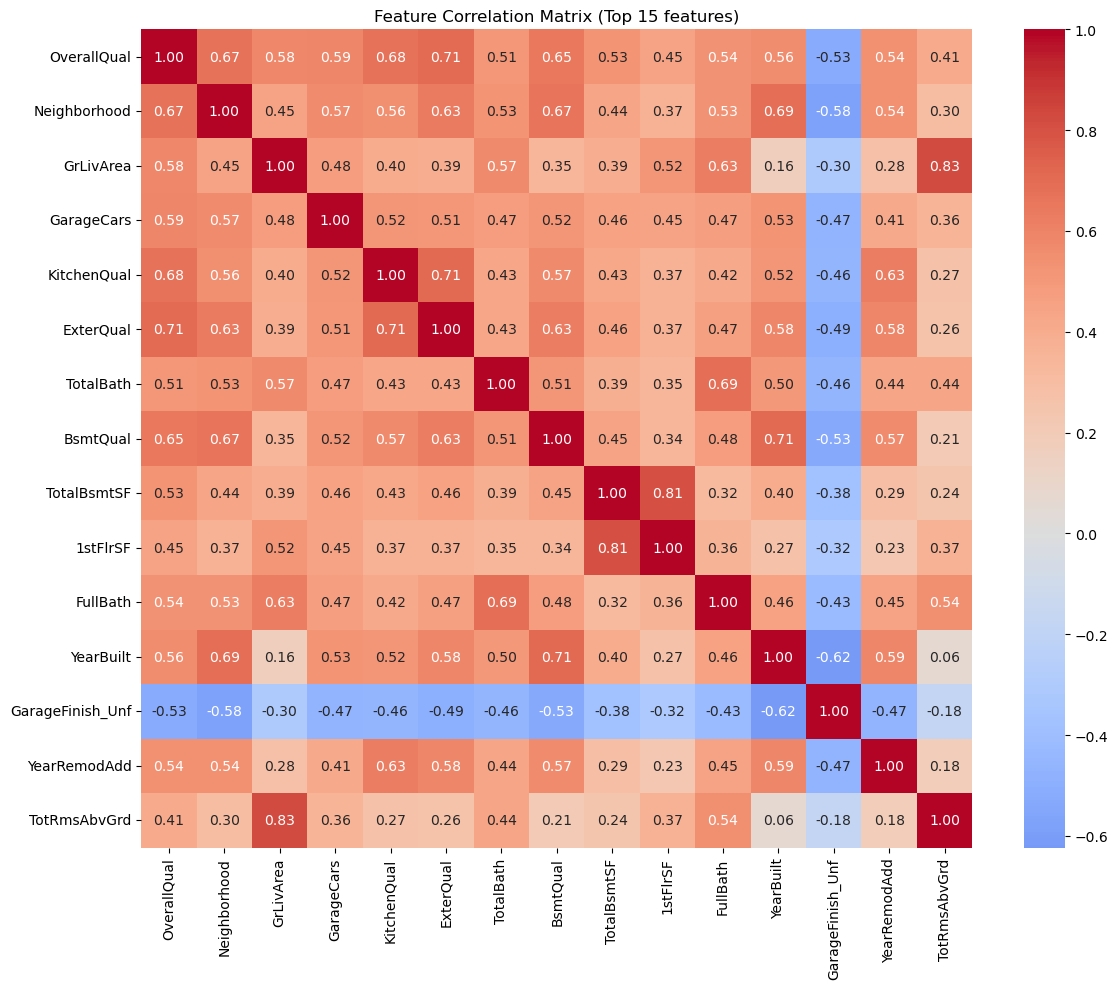

In [17]:
corr_with_target = X_train_corr.corrwith(y_train).abs().sort_values(ascending=False)
top_features = corr_with_target.head(15).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(
    X_train_corr[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Matrix (Top 15 features)')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe = RFE(estimator=LinearRegression(), n_features_to_select=50)
rfe.fit(X_train_corr, y_train)

selected_rfe = X_train_corr.columns[rfe.support_].tolist()

X_train_rfe = X_train_corr[selected_rfe]
X_test_rfe  = X_test_corr[selected_rfe]

print(f"RFE selected {len(selected_rfe)} features")
print(selected_rfe)

RFE selected 50 features
['OverallQual', 'ExterQual', 'BsmtQual', 'Fireplaces', 'GarageCars', 'TotalBath', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Alley_Pave', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR3', 'LandSlope_Mod', 'LandSlope_Sev', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'RoofStyle_Gambrel', 'RoofStyle_Shed', 'RoofMatl_Metal', 'RoofMatl_WdShngl', 'Foundation_Stone', 'Heating_GasA', 'Heating_GasW', 'Heating_Grav', 'CentralAir_Y', 'Functional_Maj2', 'Functional_Sev', 'MiscFeature_Othr', 'MiscFeature_TenC', 'SaleType_CWD', 'SaleType_Con', 'SaleType_New', 'SaleType_Oth', 'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'BsmtExposure_Gd', 'BsmtFinType1_Unf', 'BsmtFinType2_BLQ', 'Condition1_Feedr', 'Condition1_Norm', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRNe', 'Condition2_Feedr', 'Condition2_PosA', 'Condition2_RRAn']


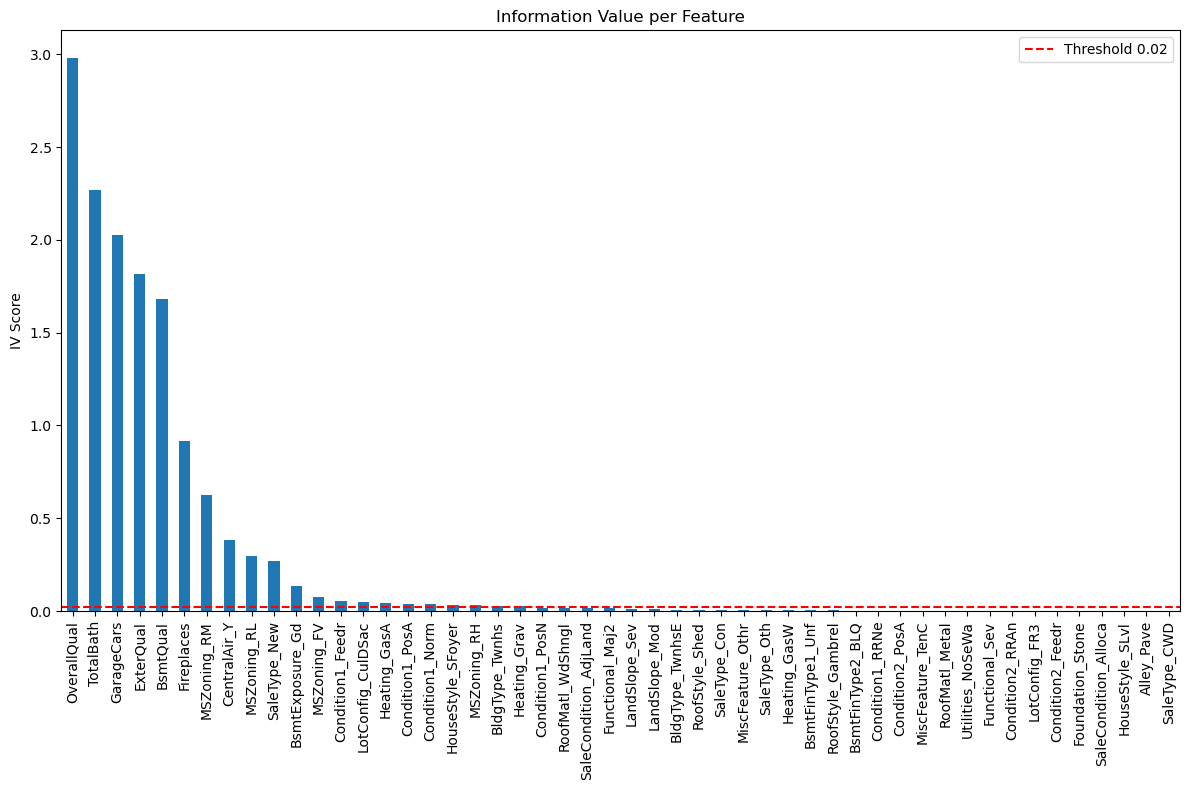


Weak features (IV < 0.02): 29
['Condition1_PosN', 'RoofMatl_WdShngl', 'SaleCondition_AdjLand', 'Functional_Maj2', 'LandSlope_Sev', 'LandSlope_Mod', 'BldgType_TwnhsE', 'RoofStyle_Shed', 'SaleType_Con', 'MiscFeature_Othr', 'SaleType_Oth', 'Heating_GasW', 'BsmtFinType1_Unf', 'RoofStyle_Gambrel', 'BsmtFinType2_BLQ', 'Condition1_RRNe', 'Condition2_PosA', 'MiscFeature_TenC', 'RoofMatl_Metal', 'Utilities_NoSeWa', 'Functional_Sev', 'Condition2_RRAn', 'LotConfig_FR3', 'Condition2_Feedr', 'Foundation_Stone', 'SaleCondition_Alloca', 'HouseStyle_SLvl', 'Alley_Pave', 'SaleType_CWD']

Shape after IV filter: (1166, 21)


In [19]:
y_binary = (y_train > y_train.median()).astype(int)

def calculate_iv(X, y_binary):
    iv_scores = {}
    total_ev  = y_binary.sum()
    total_nev = (1 - y_binary).sum()

    for col in X.columns:
        if X[col].nunique() > 10:
            try:
                bins = pd.qcut(X[col], q=10, duplicates='drop')
            except:
                bins = X[col]
        else:
            bins = X[col]

        iv = 0
        for val in bins.unique():
            mask      = bins == val
            events    = y_binary[mask].sum()
            non_events = (1 - y_binary[mask]).sum()
            dist_ev   = (events + 0.5) / total_ev
            dist_nev  = (non_events + 0.5) / total_nev
            iv       += (dist_ev - dist_nev) * np.log(dist_ev / dist_nev)

        iv_scores[col] = iv

    return pd.Series(iv_scores).sort_values(ascending=False)

iv_scores = calculate_iv(X_train_rfe, y_binary)

plt.figure(figsize=(12, 8))
iv_scores.plot(kind='bar')
plt.axhline(y=0.02, color='red', linestyle='--', label='Threshold 0.02')
plt.title('Information Value per Feature')
plt.ylabel('IV Score')
plt.legend()
plt.tight_layout()
plt.show()

weak_features = iv_scores[iv_scores < 0.02].index.tolist()
print(f"\nWeak features (IV < 0.02): {len(weak_features)}")
print(weak_features)

X_train_iv = X_train_rfe.drop(columns=weak_features)
X_test_iv  = X_test_rfe.drop(columns=weak_features)

print(f"\nShape after IV filter: {X_train_iv.shape}")

Model Training


In [20]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    cv = cross_validate(
        model, X_tr, y_tr,
        cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2'],
        return_train_score=True
    )
    train_rmse = -cv['train_neg_root_mean_squared_error'].mean()
    val_rmse   = -cv['test_neg_root_mean_squared_error'].mean()
    train_r2   =  cv['train_r2'].mean()
    val_r2     =  cv['test_r2'].mean()

    model.fit(X_tr, y_tr)
    test_preds = model.predict(X_te)
    test_rmse  = np.sqrt(mean_squared_error(y_te, test_preds))
    test_r2    = r2_score(y_te, test_preds)

    return {
        'train_rmse': train_rmse, 'val_rmse': val_rmse, 'test_rmse': test_rmse,
        'train_r2':   train_r2,   'val_r2':   val_r2,   'test_r2':   test_r2
    }

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

mlflow.set_experiment("linear_regression")

feature_sets = {
    'all_features':  (X_train_corr, X_test_corr),
    'rfe_features':  (X_train_rfe,  X_test_rfe),
    'iv_features':   (X_train_iv,   X_test_iv)
}

for fs_name, (X_tr, X_te) in feature_sets.items():
    with mlflow.start_run(run_name=f"LR_{fs_name}"):
        mlflow.set_tag("model_type", "LinearRegression")
        mlflow.set_tag("feature_set", fs_name)

        model = LinearRegression()
        metrics = evaluate_model(model, X_tr, X_te, y_train, y_test)

        mlflow.log_param("feature_set", fs_name)
        mlflow.log_param("n_features",  X_tr.shape[1])

        mlflow.log_metric("train_rmse", metrics['train_rmse'])
        mlflow.log_metric("val_rmse",   metrics['val_rmse'])
        mlflow.log_metric("test_rmse",  metrics['test_rmse'])
        mlflow.log_metric("train_r2",   metrics['train_r2'])
        mlflow.log_metric("val_r2",     metrics['val_r2'])
        mlflow.log_metric("test_r2",    metrics['test_r2'])

        mlflow.sklearn.log_model(model, name="model")

        print(f"LR_{fs_name} | val_rmse={metrics['val_rmse']:.4f} | test_rmse={metrics['test_rmse']:.4f} | test_r2={metrics['test_r2']:.4f}")

2026/04/07 20:47:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:47:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_all_features | val_rmse=0.1332 | test_rmse=0.2679 | test_r2=0.6153
🏃 View run LR_all_features at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1/runs/8f8e604d8c984fdea85df02418801b89
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1


2026/04/07 20:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:47:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_rfe_features | val_rmse=0.1544 | test_rmse=0.1716 | test_r2=0.8421
🏃 View run LR_rfe_features at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1/runs/707186d5f9fc47f4ad47118bd9bfe3ae
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1


2026/04/07 20:48:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:48:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_iv_features | val_rmse=0.1589 | test_rmse=0.1802 | test_r2=0.8260
🏃 View run LR_iv_features at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1/runs/c7126e40a602407a9294f460a6e21619
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/1


Ridge Regression


In [23]:
from sklearn.linear_model import Ridge

mlflow.set_experiment("ridge_regression")

param_grid = [
    {"alpha": 0.01},
    {"alpha": 0.1},
    {"alpha": 1.0},
    {"alpha": 10.0},
    {"alpha": 50.0},
    {"alpha": 100.0},
    {"alpha": 500.0},
]

for params in param_grid:
    with mlflow.start_run(run_name=f"Ridge_alpha{params['alpha']}"):
        mlflow.set_tag("model_type", "Ridge")

        model = Ridge(**params)
        metrics = evaluate_model(model, X_train_rfe, X_test_rfe, y_train, y_test)

        mlflow.log_params(params)
        mlflow.log_metric("train_rmse", metrics['train_rmse'])
        mlflow.log_metric("val_rmse",   metrics['val_rmse'])
        mlflow.log_metric("test_rmse",  metrics['test_rmse'])
        mlflow.log_metric("train_r2",   metrics['train_r2'])
        mlflow.log_metric("val_r2",     metrics['val_r2'])
        mlflow.log_metric("test_r2",    metrics['test_r2'])

        mlflow.sklearn.log_model(model, name="model")

        print(f"alpha={params['alpha']:>6} | val_rmse={metrics['val_rmse']:.4f} | test_rmse={metrics['test_rmse']:.4f} | test_r2={metrics['test_r2']:.4f}")

2026/04/07 20:48:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:48:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=  0.01 | val_rmse=0.1542 | test_rmse=0.1717 | test_r2=0.8421
🏃 View run Ridge_alpha0.01 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2/runs/5e690f8692ba44c29956faa018ca35c5
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2


2026/04/07 20:49:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:49:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=   0.1 | val_rmse=0.1526 | test_rmse=0.1719 | test_r2=0.8416
🏃 View run Ridge_alpha0.1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2/runs/0bcc8ff0d6d74e64938186712780e932
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2


2026/04/07 20:49:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:49:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

alpha=  50.0 | val_rmse=0.1554 | test_rmse=0.1745 | test_r2=0.8368
🏃 View run Ridge_alpha50.0 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2/runs/57fb6fa2b3dc403ba717c62be4cb4638
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2


2026/04/07 20:50:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:51:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha= 100.0 | val_rmse=0.1586 | test_rmse=0.1762 | test_r2=0.8337
🏃 View run Ridge_alpha100.0 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2/runs/fcaba0e59a944d49bb2fcf9c371d31da
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2


2026/04/07 20:51:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:51:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha= 500.0 | val_rmse=0.1757 | test_rmse=0.1899 | test_r2=0.8067
🏃 View run Ridge_alpha500.0 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2/runs/3978063a8b984f3491dbc7bed8ac4cdf
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/2


Lasso Regression

In [24]:
from sklearn.linear_model import Lasso

mlflow.set_experiment("lasso_regression")

param_grid = [
    {"alpha": 0.0001},
    {"alpha": 0.0005},
    {"alpha": 0.001},
    {"alpha": 0.005},
    {"alpha": 0.01},
    {"alpha": 0.05},
    {"alpha": 0.1},
]

for params in param_grid:
    with mlflow.start_run(run_name=f"Lasso_alpha{params['alpha']}"):
        mlflow.set_tag("model_type", "Lasso")

        model = Lasso(**params, max_iter=10000)
        metrics = evaluate_model(model, X_train_rfe, X_test_rfe, y_train, y_test)

        mlflow.log_params(params)
        mlflow.log_metric("train_rmse", metrics['train_rmse'])
        mlflow.log_metric("val_rmse",   metrics['val_rmse'])
        mlflow.log_metric("test_rmse",  metrics['test_rmse'])
        mlflow.log_metric("train_r2",   metrics['train_r2'])
        mlflow.log_metric("val_r2",     metrics['val_r2'])
        mlflow.log_metric("test_r2",    metrics['test_r2'])

        model.fit(X_train_rfe, y_train)
        n_zero = (model.coef_ == 0).sum()
        mlflow.log_metric("zeroed_features", n_zero)

        mlflow.sklearn.log_model(model, name="model")

        print(f"alpha={params['alpha']:>6} | val_rmse={metrics['val_rmse']:.4f} | test_rmse={metrics['test_rmse']:.4f} | zeroed={n_zero}")

2026/04/07 20:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=0.0001 | val_rmse=0.1509 | test_rmse=0.1702 | zeroed=4
🏃 View run Lasso_alpha0.0001 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3/runs/fb367875b309484b93787a979fa96654
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3


2026/04/07 20:52:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=0.0005 | val_rmse=0.1510 | test_rmse=0.1724 | zeroed=20
🏃 View run Lasso_alpha0.0005 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3/runs/cec37756389a49b489b4b891bb2eb731
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3


2026/04/07 20:53:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

alpha=  0.01 | val_rmse=0.1702 | test_rmse=0.1869 | zeroed=41
🏃 View run Lasso_alpha0.01 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3/runs/67b1f93a75bc451dbd3dc0e06dda0f1a
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3


2026/04/07 20:54:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=  0.05 | val_rmse=0.1991 | test_rmse=0.2134 | zeroed=47
🏃 View run Lasso_alpha0.05 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3/runs/f2cd15359850483dac6ff669f0ab36ff
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3


2026/04/07 20:55:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


alpha=   0.1 | val_rmse=0.2362 | test_rmse=0.2500 | zeroed=48
🏃 View run Lasso_alpha0.1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3/runs/e14205dd05ad493fb506c86d46c24970
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/3


Decision Tree


In [25]:
from sklearn.tree import DecisionTreeRegressor

mlflow.set_experiment("decision_tree")

param_grid_dt = [
    {"max_depth": 3,    "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 3,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 3,    "min_samples_split": 10, "min_samples_leaf": 4},

    {"max_depth": 5,    "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 5,    "min_samples_split": 10, "min_samples_leaf": 4},

    {"max_depth": 10,   "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 10,   "min_samples_split": 10, "min_samples_leaf": 4},

    {"max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5},
]

for params in param_grid_dt:
    run_name = f"DT_depth{params['max_depth']}_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "DecisionTree")

        model = DecisionTreeRegressor(**params, random_state=42)
        metrics = evaluate_model(model, X_train_rfe, X_test_rfe, y_train, y_test)

        mlflow.log_params(params)
        mlflow.log_metric("train_rmse", metrics['train_rmse'])
        mlflow.log_metric("val_rmse",   metrics['val_rmse'])
        mlflow.log_metric("test_rmse",  metrics['test_rmse'])
        mlflow.log_metric("train_r2",   metrics['train_r2'])
        mlflow.log_metric("val_r2",     metrics['val_r2'])
        mlflow.log_metric("test_r2",    metrics['test_r2'])

        mlflow.sklearn.log_model(model, name="model")

        print(f"depth={str(params['max_depth']):>4} split={params['min_samples_split']:>2} leaf={params['min_samples_leaf']:>1} | "
              f"val_rmse={metrics['val_rmse']:.4f} | test_rmse={metrics['test_rmse']:.4f} | test_r2={metrics['test_r2']:.4f}")

2026/04/07 21:05:18 INFO mlflow.tracking.fluent: Experiment with name 'decision_tree' does not exist. Creating a new experiment.
2026/04/07 21:05:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


depth=   3 split= 2 leaf=1 | val_rmse=0.2206 | test_rmse=0.2368 | test_r2=0.6996
🏃 View run DT_depth3_split2_leaf1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4/runs/72160d7c43924560a7625a9f0a3a262a
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4


2026/04/07 21:05:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


depth=   3 split= 5 leaf=2 | val_rmse=0.2206 | test_rmse=0.2368 | test_r2=0.6996
🏃 View run DT_depth3_split5_leaf2 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4/runs/c6a76552a07a4fd7ae906169ffdb25b5
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4


2026/04/07 21:06:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

depth=  10 split=10 leaf=4 | val_rmse=0.1850 | test_rmse=0.1900 | test_r2=0.8066
🏃 View run DT_depth10_split10_leaf4 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4/runs/44040992e90740bd92ad717408210f54
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4


2026/04/07 21:09:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


depth=None split= 2 leaf=1 | val_rmse=0.2079 | test_rmse=0.2084 | test_r2=0.7673
🏃 View run DT_depthNone_split2_leaf1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4/runs/813f0a6fd92e47378a3ca8808f92394d
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4


2026/04/07 21:10:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


depth=None split=10 leaf=5 | val_rmse=0.1813 | test_rmse=0.1917 | test_r2=0.8030
🏃 View run DT_depthNone_split10_leaf5 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4/runs/947bd53b04e44b60b506ec90f70e7e57
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/4


Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

mlflow.set_experiment("random_forest")

param_grid_rf = [
    {"n_estimators": 10,  "max_depth": 3,    "min_samples_leaf": 4},
    {"n_estimators": 10,  "max_depth": 5,    "min_samples_leaf": 4},

    {"n_estimators": 50,  "max_depth": 5,    "min_samples_leaf": 2},
    {"n_estimators": 50,  "max_depth": 10,   "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 15,   "min_samples_leaf": 1},

    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
]

for params in param_grid_rf:
    run_name = f"RF_n{params['n_estimators']}_depth{params['max_depth']}_leaf{params['min_samples_leaf']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "RandomForest")

        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        metrics = evaluate_model(model, X_train_rfe, X_test_rfe, y_train, y_test)

        mlflow.log_params(params)
        mlflow.log_metric("train_rmse", metrics['train_rmse'])
        mlflow.log_metric("val_rmse",   metrics['val_rmse'])
        mlflow.log_metric("test_rmse",  metrics['test_rmse'])
        mlflow.log_metric("train_r2",   metrics['train_r2'])
        mlflow.log_metric("val_r2",     metrics['val_r2'])
        mlflow.log_metric("test_r2",    metrics['test_r2'])

        mlflow.sklearn.log_model(model, name="model")

        print(f"n={params['n_estimators']:>3} depth={str(params['max_depth']):>4} leaf={params['min_samples_leaf']} | "
              f"val_rmse={metrics['val_rmse']:.4f} | test_rmse={metrics['test_rmse']:.4f} | test_r2={metrics['test_r2']:.4f}")

2026/04/09 14:18:11 INFO mlflow.tracking.fluent: Experiment with name 'random_forest' does not exist. Creating a new experiment.
2026/04/09 14:18:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


n= 10 depth=   3 leaf=4 | val_rmse=0.2004 | test_rmse=0.2169 | test_r2=0.7478
🏃 View run RF_n10_depth3_leaf4 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5/runs/d93b92f05e18432db94618bef5af17f2
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5


2026/04/09 14:18:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


n= 10 depth=   5 leaf=4 | val_rmse=0.1762 | test_rmse=0.1901 | test_r2=0.8064
🏃 View run RF_n10_depth5_leaf4 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5/runs/207242fcf2ef44dda5c3d77b398d2359
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5


2026/04/09 14:19:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

n=100 depth=  15 leaf=1 | val_rmse=0.1673 | test_rmse=0.1765 | test_r2=0.8330
🏃 View run RF_n100_depth15_leaf1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5/runs/5a9bbe0d7886496bb5bbb6fa0f4b6c36
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5


2026/04/09 14:21:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


n=200 depth=None leaf=1 | val_rmse=0.1678 | test_rmse=0.1769 | test_r2=0.8322
🏃 View run RF_n200_depthNone_leaf1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5/runs/d7d5d0e2c89c4351808bc4ef00ccdd4b
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5


2026/04/09 14:21:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


n=300 depth=None leaf=1 | val_rmse=0.1673 | test_rmse=0.1761 | test_r2=0.8338
🏃 View run RF_n300_depthNone_leaf1 at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5/runs/82c57f38967745b1b725cbdee48991f2
🧪 View experiment at: https://dagshub.com/sansi23/House-Prices---Advanced-Regression-Techniques.mlflow/#/experiments/5


Create Model

In [28]:
client = mlflow.tracking.MlflowClient()
version = client.create_model_version(
    name="house_prices_best_model",
    source="mlflow-artifacts:/2e186dfa4af14561a0ac249bc879344a/models/m-cc8585eeef7e417d993acf958882dbd7/artifacts",
    run_id="fb367875b309484b93787a979fa96654"
)
print("Version:", version.version)
print("Status:", version.status)

2026/04/09 14:55:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_prices_best_model, version 1


Version: 1
Status: READY


In [32]:
client = mlflow.tracking.MlflowClient()
version = client.create_model_version(
    name="house_prices_best_model",
    source="mlflow-artifacts:/25b4199b21d641b9bb1bb879714fe3f5/models/m-1bab93f0b2fb48b8831a615d4734486f/artifacts",
    run_id="2c9a804e3fb54fd183e1781370825939"
)
print("Version:", version.version)
print("Status:", version.status)

2026/04/09 15:23:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_prices_best_model, version 2


Version: 2
Status: READY
